In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def plot_func(f, K_cutoff):
    x = np.linspace(0.0, 2.*np.pi*30, 100)
    y = f(x)
    plt.plot(x/K_cutoff, y)
    plt.show()

In [4]:
def compute_S0(x, D, H, alpha, K_cutoff):
    S0 = np.where(x < K_cutoff, D * (1 - H) * (x**alpha) + H, 1.0)
    return S0

def compute_bump(x, K_cutoff):
    A = 0.5                  # Height of the hill
    x0 = 0.95                # Center of the hill before cutoff
    sigma = 0.05             # Width of the hill
    bump = 1 + A * np.exp(-((x - x0)**2) / (2 * sigma**2))
    #bump = np.where(x < K_cutoff, bump, 0.0)
    return bump

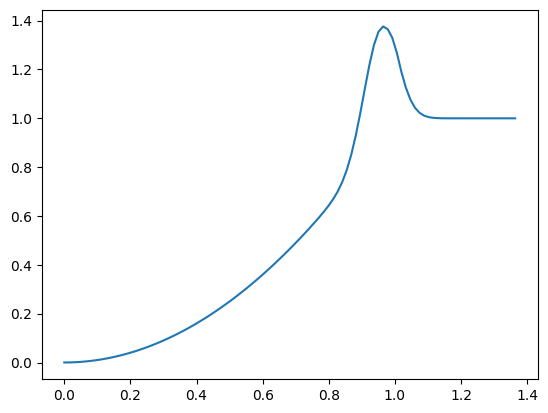

In [5]:
H = 1e-4
alpha = 2.
K_cutoff = 44*np.pi
D = np.pow(K_cutoff, -alpha)

f = lambda x : compute_S0(x, D, H, alpha, K_cutoff) * compute_bump(x/K_cutoff, K_cutoff)
plot_func(f, K_cutoff)

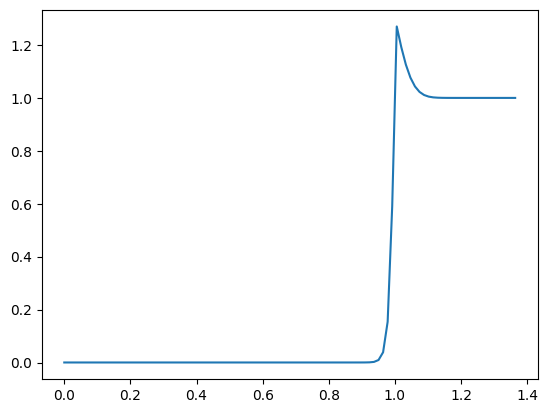

In [6]:
H = 1e-4
alpha = 100.
K_cutoff = 44*np.pi
D = np.pow(K_cutoff, -alpha)

f = lambda x : compute_S0(x, D, H, alpha, K_cutoff) * compute_bump(x/K_cutoff, K_cutoff)
plot_func(f, K_cutoff)

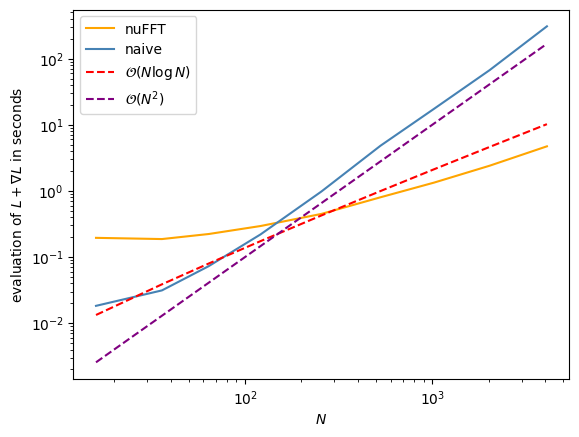

In [46]:
# plotting of benchmarks

Ns = np.array([16, 36, 64, 121, 256, 529, 1024, 2025, 4096])
Ms = [27, 49, 97, 189, 391, 860, 1652, 3199, 6497]
o_ts = [0.06537279998883605, 0.0569135001860559, 0.06550460029393435, 0.07958010025322437, 0.13674599956721067, 0.24409399973228574, 0.3958451999351382, 0.8315373999066651, 1.5917062000371516]
g_ts = [0.12980940006673336, 0.13020530017092824, 0.15755830006673932, 0.21499490039423108, 0.31260429974645376, 0.5572060998529196, 0.9415964996442199, 1.5737050003372133, 3.1320548998191953]

o2_ts = [0.0055323997512459755, 0.013050300069153309, 0.027522699907422066, 0.05829979991540313, 0.29521889984607697, 1.3952653999440372, 5.387087299954146, 19.158347900025547, 94.25004460010678]
g2_ts = [0.012760000303387642, 0.018269000109285116, 0.045368900056928396, 0.16166300000622869, 0.6860070000402629, 3.428167900070548, 12.117141699884087, 47.91367059992626, 213.95637860009447]

plt.loglog(Ns, np.array(o_ts) + np.array(g_ts), color="orange", label="nuFFT")

plt.loglog(Ns, np.array(o2_ts) + np.array(g2_ts), color="steelblue", label="naive")

plt.loglog(Ns, 0.0003*Ns*np.log(Ns), linestyle="dashed", color="red", label=r"$\mathcal{O}(N\log N)$")
plt.loglog(Ns, 0.00001*Ns**2, linestyle="dashed", color="purple", label=r"$\mathcal{O}(N^2)$")

plt.xlabel(r"$N$")
plt.ylabel(r"evaluation of $L + \nabla L$ in seconds")
plt.legend()
plt.show()

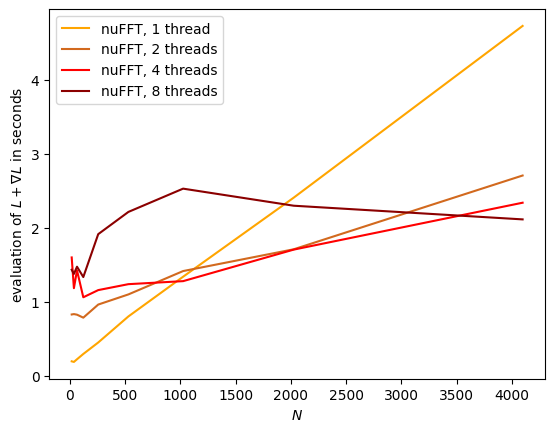

In [45]:
plt.plot(Ns, np.array(o_ts) + np.array(g_ts), color="orange", label="nuFFT, 1 thread")

o_ts_2threads = [0.2362375999800861, 0.20123480027541518, 0.2175215999595821, 0.20420240005478263, 0.30535810021683574, 0.3003038000315428, 0.41003020014613867, 0.5127274999395013, 0.903600700199604]
g_ts_2threads = [0.5915025998838246, 0.631482099648565, 0.6073908000253141, 0.5805410998873413, 0.6563253998756409, 0.7982838000170887, 1.0038554999046028, 1.1952626998536289, 1.800366799812764]

plt.plot(Ns, np.array(o_ts_2threads) + np.array(g_ts_2threads), color="chocolate", label="nuFFT, 2 threads")

o_ts_4threads = [0.36276290006935596, 0.25719489995390177, 0.3867658004164696, 0.25109799997881055, 0.29954580031335354, 0.3304006000980735, 0.365087500307709, 0.4850465999916196, 0.7148213000036776]
g_ts_4threads = [1.2351199998520315, 0.9257253999821842, 1.0367527999915183, 0.8088998002931476, 0.8573079002089798, 0.9066086001694202, 0.9127306998707354, 1.218501899857074, 1.6219084998592734]

plt.plot(Ns, np.array(o_ts_4threads) + np.array(g_ts_4threads), color="red", label="nuFFT, 4 threads")

o_ts_8threads = [0.3349411999806762, 0.29707490000873804, 0.405749199911952, 0.33641160000115633, 0.6046196999959648, 0.6631026002578437, 0.9120551003143191, 0.7455416000448167, 0.6102908998727798]
g_ts_8threads = [1.096819099970162, 1.0785015998408198, 1.067039499990642, 0.9966621999628842, 1.3076212001033127, 1.549281599931419, 1.6146698999218643, 1.5506440997123718, 1.5013260999694467]

plt.plot(Ns, np.array(o_ts_8threads) + np.array(g_ts_8threads), color="darkred", label="nuFFT, 8 threads")

plt.xlabel(r"$N$")
plt.ylabel(r"evaluation of $L + \nabla L$ in seconds")
plt.legend()
plt.show()